## Inteligență Artificială  Tema 1 - 2025: Sokoban

Responsabili:
- Andrei Olaru
- Cătălin Chiru
- Andrei Dugăeșescu
- Mihai Nan
- Vlad Matei Drăghici
- Alexandru Baciu
- Bogdan-Andrei Sprîncenatu

# Imports

In [3]:
from sokoban import Map, save_images, create_gif
import time
from search_methods.lrta_star import LRTAStar
from search_methods.simmulated_annealing import SimulatedAnnealing
import matplotlib.pyplot as plt
import numpy as np
import os

# Test Map

In [4]:
test_maps = [
    'tests/easy_map1.yaml',
    'tests/easy_map2.yaml',
    'tests/medium_map1.yaml',
    'tests/medium_map2.yaml',
    'tests/hard_map1.yaml',
    'tests/hard_map2.yaml',
    'tests/large_map1.yaml',
    'tests/large_map2.yaml',
    'tests/super_hard_map1.yaml'
]

# Test LRTA* solver

Testing LRTA* solver:
Solution found with 178 moves
Pull moves used: 36
Time taken: 100.89 seconds

Initial state:


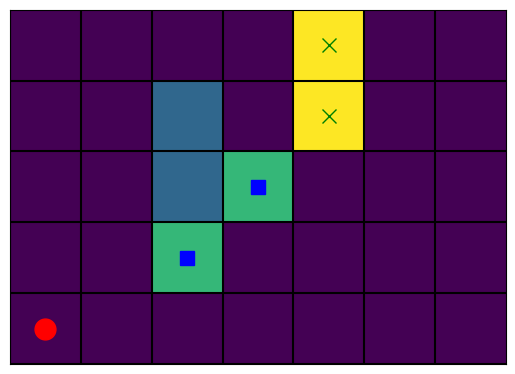


Final state:


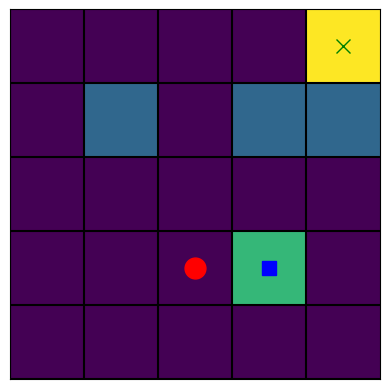

In [5]:
sokoban_map = Map.from_yaml(test_maps[1])
print("Testing LRTA* solver:")
lrta_solver = LRTAStar(max_iterations=200000)
start_time = time.time()
solution = lrta_solver.solve(sokoban_map)
solve_time = time.time() - start_time
if solution:
    print(f"Solution found with {len(solution)} moves")
    print(f"Pull moves used: {sum(1 for move in solution if move >= 4)}")
    print(f"Time taken: {solve_time:.2f} seconds")

    # Show final state after LRTA*
    final_state = Map.from_yaml(test_maps[1])
    for move in solution:
        if final_state.is_valid_move(move):
            final_state.apply_move(move)
    print("\nInitial state:")
    sokoban_map.plot_map()
    print("\nFinal state:")
    final_state.plot_map()
    final_state.save_map('images', 'lrta_solution.png')

# Test Simulated easy

In [6]:
sa_solver = SimulatedAnnealing(initial_temp=100, cooling_rate=0.99)
start_time = time.time()
sokoban_map = Map.from_yaml('tests/easy_map1.yaml')
solution = sa_solver.solve(sokoban_map)
solve_time = time.time() - start_time

if solution:
    print(f"Solution found with {len(solution)} moves")
    print(f"Pull moves used: {sum(1 for move in solution if move >= 4)}")
    print(f"Time taken: {solve_time:.2f} seconds")

    # Show final state after Simulated Annealing
    final_state = Map.from_yaml('tests/easy_map1.yaml')
    for move in solution:
        final_state.apply_move(move)
    print("\nInitial state:")
    sokoban_map.plot_map()
    print("\nFinal state:")
    final_state.plot_map()
    final_state.save_map('images', 'sa_solution.png')

# Test Both  LRTA* and Simulated Annealing with all maps


Running LRTA* tests...

Testing easy_map1 with LRTAStar


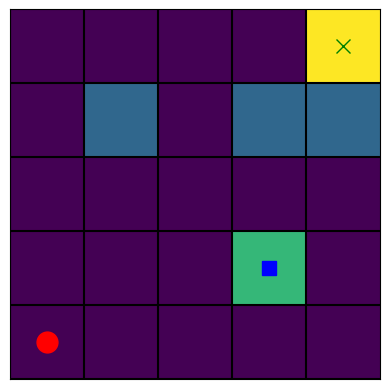

✗ No solution found

Testing easy_map2 with LRTAStar


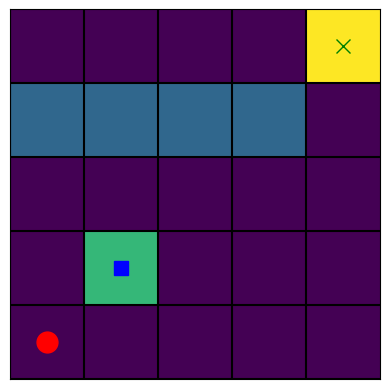

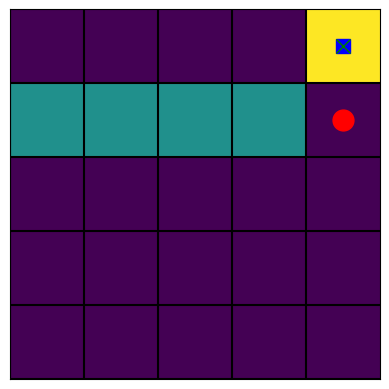

✓ Solved in 0.01s with 55 moves (8 pulls)

Testing medium_map1 with LRTAStar


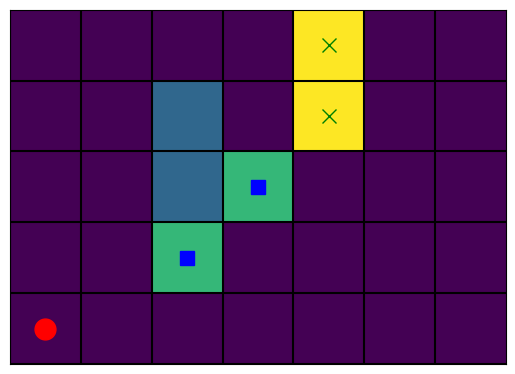

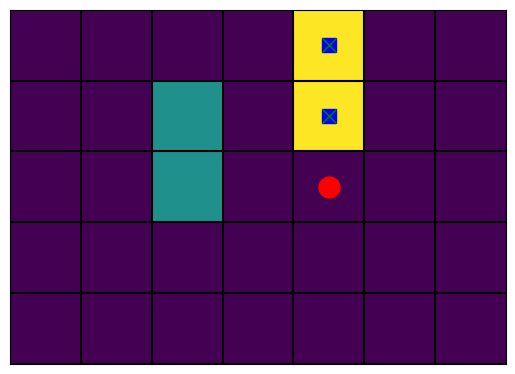

✓ Solved in 96.17s with 178 moves (36 pulls)

Testing medium_map2 with LRTAStar


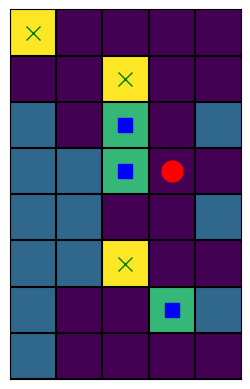

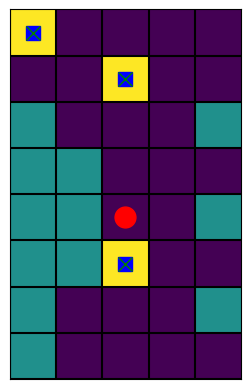

✓ Solved in 23.11s with 1622 moves (350 pulls)

Testing hard_map1 with LRTAStar


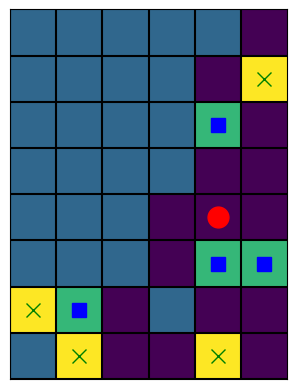

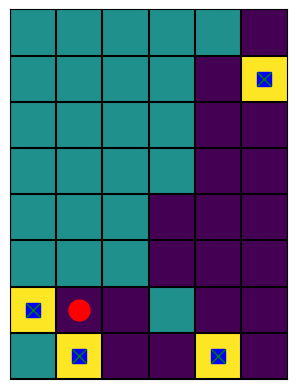

✓ Solved in 3.76s with 639 moves (197 pulls)

Testing hard_map2 with LRTAStar


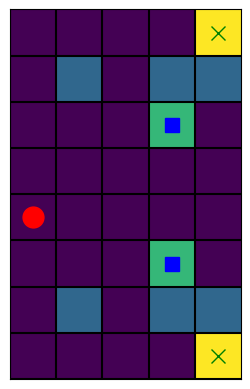

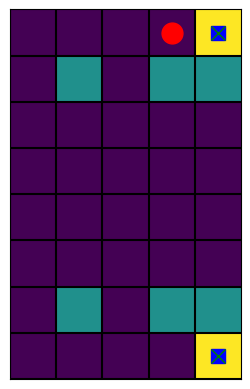

✓ Solved in 3.83s with 1835 moves (408 pulls)

Testing large_map1 with LRTAStar


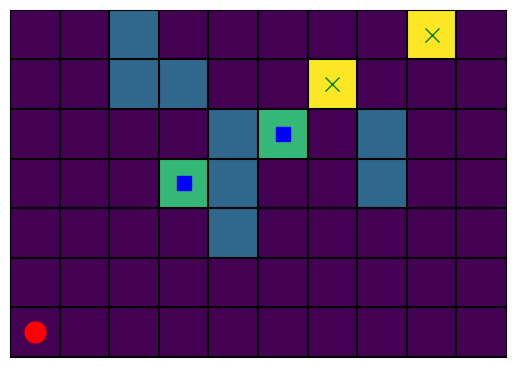

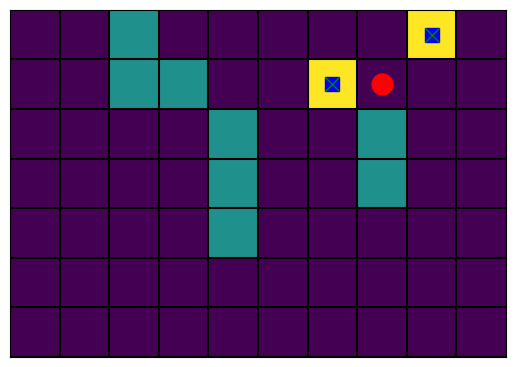

✓ Solved in 22.31s with 4690 moves (927 pulls)

Testing large_map2 with LRTAStar


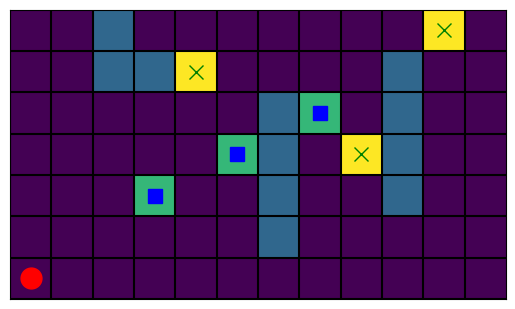

KeyboardInterrupt: 

In [7]:
# Function to run solver and collect metrics
def run_solver_test(solver, map_file, timeout=300):  # 5 minute timeout
    results = {}
    map_name = os.path.basename(map_file).replace('.yaml', '')
    print(f"\nTesting {map_name} with {solver.__class__.__name__}")

    try:
        # Load map
        sokoban_map = Map.from_yaml(map_file)
        sokoban_map.plot_map()

        # Run solver with timeout
        start_time = time.time()
        solution = solver.solve(sokoban_map)
        solve_time = time.time() - start_time

        if solution:
            results = {
                'status': 'solved',
                'time': solve_time,
                'moves': len(solution),
                'pull_moves': sum(1 for move in solution if move >= 4)
            }
            # print solution map
            final_state = Map.from_yaml(map_file)
            for move in solution:
                final_state.apply_move(move)
            final_state.plot_map()

            print(f"✓ Solved in {solve_time:.2f}s with {len(solution)} moves ({results['pull_moves']} pulls)")
        else:
            results = {
                'status': 'failed',
                'time': solve_time,
                'moves': 0,
                'pull_moves': 0
            }
            print("✗ No solution found")

    except Exception as e:
        results = {
            'status': 'error',
            'time': 0,
            'moves': 0,
            'pull_moves': 0,
            'error': str(e)
        }
        print(f"✗ Error: {str(e)}")

    return results

# Test both solvers
results = {
    'LRTA*': {},
    'SimulatedAnnealing': {}
}

# Run LRTA* tests
print("\nRunning LRTA* tests...")
for map_file in test_maps:
    solver = LRTAStar(max_iterations=600000)
    results['LRTA*'][map_file] = run_solver_test(solver, map_file)

# Run Simulated Annealing tests
print("\nRunning Simulated Annealing tests...")
for map_file in test_maps:
    solver = SimulatedAnnealing(initial_temp=100, cooling_rate=0.99, max_iterations=400000)
    results['SimulatedAnnealing'][map_file] = run_solver_test(solver, map_file)

# Create comparison plots
def plot_comparison(metric='time', title=None):
    plt.figure(figsize=(15, 6))

    map_names = [os.path.basename(m).replace('.yaml', '') for m in test_maps]
    x = np.arange(len(map_names))
    width = 0.35

    lrta_values = [results['LRTA*'][m][metric] for m in test_maps]
    sa_values = [results['SimulatedAnnealing'][m][metric] for m in test_maps]

    plt.bar(x - width/2, lrta_values, width, label='LRTA*')
    plt.bar(x + width/2, sa_values, width, label='Simulated Annealing')

    plt.xlabel('Maps')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.title(title or f'{metric.replace("_", " ").title()} Comparison')
    plt.xticks(x, map_names, rotation=45)
    plt.legend()

    if metric == 'time':
        plt.yscale('log')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Generate comparison plots
plot_comparison('time', 'Runtime Comparison (seconds)')
plot_comparison('moves', 'Total Moves Comparison')
plot_comparison('pull_moves', 'Pull Moves Comparison')

# Print summary statistics
print("\nSummary Statistics:")
print("-" * 50)
for solver_name in results:
    print(f"\n{solver_name}:")
    solved = sum(1 for m in test_maps if results[solver_name][m]['status'] == 'solved')
    avg_time = np.mean([results[solver_name][m]['time'] for m in test_maps
                       if results[solver_name][m]['status'] == 'solved'])
    avg_moves = np.mean([results[solver_name][m]['moves'] for m in test_maps
                        if results[solver_name][m]['status'] == 'solved'])
    avg_pulls = np.mean([results[solver_name][m]['pull_moves'] for m in test_maps
                        if results[solver_name][m]['status'] == 'solved'])

    print(f"Solved {solved}/{len(test_maps)} maps")
    print(f"Average time: {avg_time:.2f}s")
    print(f"Average moves: {avg_moves:.1f}")
    print(f"Average pull moves: {avg_pulls:.1f}")